# SpaceX Falcon 9 First Stage Landing Prediction

SpaceX advertises Falcon 9 launches at around $62 million; other providers charge upward of $165 million each, largely because SpaceX can reuse the first stage. If I can predict whether the first stage will land, I have a proxy for what a launch actually costs -- useful if a competitor wanted to bid against SpaceX for a rocket launch.

Here I build the machine learning pipeline that predicts landing success from the data prepared in the previous notebooks. Most unsuccessful landings are planned -- SpaceX performs a controlled landing in the ocean rather than attempting a landing on a pad or drone ship.

## What this notebook does

Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn

We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
# Reusable evaluation/plotting logic lives in src/spacex_capstone (pip install -e .)
from spacex_capstone.models import plot_confusion_matrix, evaluate_with_stratified_kfold

This function is to plot the confusion matrix.


In [3]:
# plot_confusion_matrix is now imported from spacex_capstone.models above
# (previously defined inline here) -- same behavior, reused across notebooks.

## Load the dataframe


Load the data


In [4]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")


In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:

X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## Building the label array

Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [8]:
# to_numpy() converts the pandas Series of 0/1 landing outcomes into a plain
# NumPy array, which is the target vector (Y) scikit-learn estimators expect.
Y = data['Class'].to_numpy()

## Standardizing the features

Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [9]:
# students get this
transform = preprocessing.StandardScaler()

# Capture the original column names and values before X becomes a plain NumPy
# array below -- we need feature_names for feature importance / SHAP later,
# and X_reference (the untransformed feature table) to build realistic
# synthetic scenarios for the business-impact section at the end.
feature_names = X.columns.tolist()
X_reference = X.copy()

# fit_transform learns the mean/std of each feature in X and rescales it to
# zero mean and unit variance -- required by distance-based models like SVM and KNN.
X = transform.fit_transform(X)

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## Splitting into train and test sets

Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

we can see we only have 18 test samples.


In [11]:
Y_test.shape

(18,)

## Tuning logistic regression

Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [12]:
# C is swept over a modest, mostly-regularized range (0.01-1) since with only
# 90 samples, strong regularization helps avoid overfitting; penalty is fixed to
# l2 (ridge) rather than l1 because l1 can zero out features entirely, which is
# risky to rely on with such a small sample; 'lbfgs' is the standard efficient
# solver for l2-penalized logistic regression.
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [13]:
# C is swept over a modest, mostly-regularized range (0.01-1) since with only
# 90 samples, strong regularization helps avoid overfitting; penalty is fixed to
# l2 (ridge) rather than l1 because l1 can zero out features entirely, which is
# risky to rely on with such a small sample; 'lbfgs' is the standard efficient
# solver for l2-penalized logistic regression.
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()

# GridSearchCV exhaustively tries every combination in `parameters`, using
# 10-fold cross-validation on the training data, and keeps the best-scoring one.
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [14]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## Logistic regression: test accuracy

Calculate the accuracy on the test data using the method <code>score</code>:


In [15]:
# score() on the held-out test set gives the accuracy of the best logistic
# regression model found by GridSearchCV, on data it never saw during training.
logreg_accuracy = logreg_cv.score(X_test, Y_test)
logreg_accuracy

0.8333333333333334

Lets look at the confusion matrix:


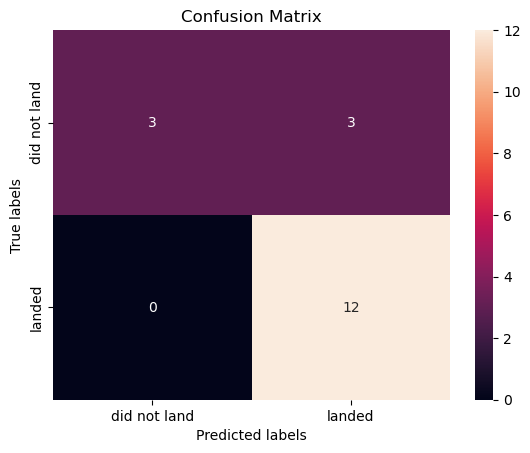

In [16]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## Tuning a support vector machine

Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [17]:
# The kernel choices span linear to non-linear boundaries so the search can pick
# the shape that actually separates the classes, rather than assuming one. C and
# gamma are swept on a log scale from 1e-3 to 1e3 because neither hyperparameter's
# right order of magnitude is known in advance -- a log-spaced grid covers many
# orders of magnitude far more efficiently than a linear one would.
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [18]:
# The kernel choices span linear to non-linear boundaries so the search can pick
# the shape that actually separates the classes, rather than assuming one. C and
# gamma are swept on a log scale from 1e-3 to 1e3 because neither hyperparameter's
# right order of magnitude is known in advance -- a log-spaced grid covers many
# orders of magnitude far more efficiently than a linear one would.
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

In [19]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## SVM: test accuracy

Calculate the accuracy on the test data using the method <code>score</code>:


In [20]:
svm_accuracy = svm_cv.score(X_test, Y_test)
svm_accuracy

0.8333333333333334

We can plot the confusion matrix


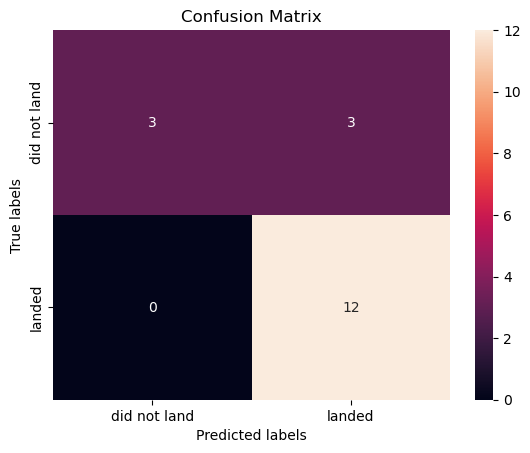

In [21]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## Tuning a decision tree

Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [22]:
# criterion/splitter let the search pick the best split rule rather than assuming
# one upfront. max_depth ranges from shallow (2) to fairly deep (18) to balance
# underfitting against the overfitting risk that's especially acute with only 90
# samples; min_samples_leaf/min_samples_split add extra regularization options to
# counteract that same risk.
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

# random_state pinned for reproducibility -- without it, splitter='random'
# makes best_params_ (and downstream results) vary slightly between runs.
tree = DecisionTreeClassifier(random_state=2)

In [23]:
# criterion/splitter let the search pick the best split rule rather than assuming
# one upfront. max_depth ranges from shallow (2) to fairly deep (18) to balance
# underfitting against the overfitting risk that's especially acute with only 90
# samples; min_samples_leaf/min_samples_split add extra regularization options to
# counteract that same risk.
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

# random_state pinned for reproducibility -- without it, splitter='random'
# makes best_params_ (and downstream results) vary slightly between runs.
tree = DecisionTreeClassifier(random_state=2)

tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/sit

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=2),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [24]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.8767857142857143


## Decision tree: test accuracy

Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [25]:
tree_accuracy = tree_cv.score(X_test, Y_test)
tree_accuracy

0.8333333333333334

We can plot the confusion matrix


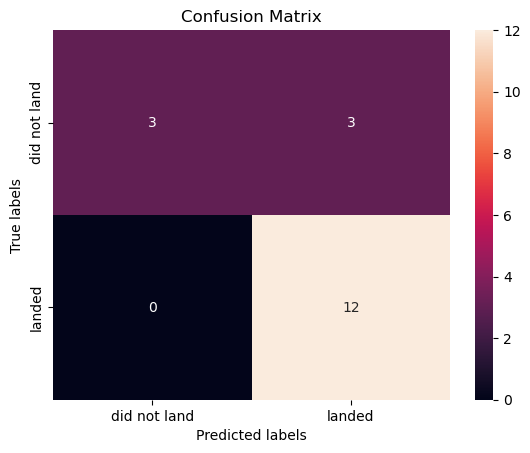

In [26]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## Tuning k-nearest neighbors

Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [27]:
# n_neighbors from 1 to 10 is a range appropriate for a 90-sample dataset -- much
# larger k would mean each prediction leans on a large fraction of the whole
# dataset. The algorithm options are just different implementations of the same
# nearest-neighbor search (included to confirm none gives a meaningfully
# different result); p=1/2 compares Manhattan vs. Euclidean distance.
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [28]:
# n_neighbors from 1 to 10 is a range appropriate for a 90-sample dataset -- much
# larger k would mean each prediction leans on a large fraction of the whole
# dataset. The algorithm options are just different implementations of the same
# nearest-neighbor search (included to confirm none gives a meaningfully
# different result); p=1/2 compares Manhattan vs. Euclidean distance.
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 415, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 764, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py", line 259, in predict
    pro

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [29]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'ball_tree', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


## KNN: test accuracy

Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [30]:
knn_accuracy = knn_cv.score(X_test, Y_test)
knn_accuracy

0.8333333333333334

We can plot the confusion matrix


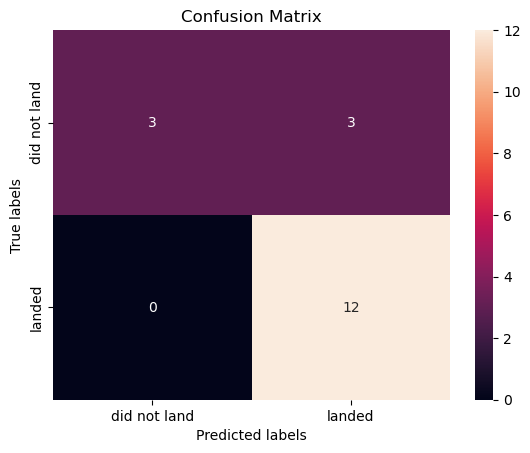

In [31]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## Comparing all four models

Find the method performs best:


In [32]:
# Collect each model's held-out test accuracy so we can compare them directly.
algorithms = {'KNN': knn_accuracy,
              'Tree': tree_accuracy,
              'LogisticRegression': logreg_accuracy,
              'SVM': svm_accuracy}

best_algorithm = max(algorithms, key=algorithms.get)
print(algorithms)
print(f"Best performing method: {best_algorithm} with test accuracy {algorithms[best_algorithm]:.4f}")

{'KNN': 0.8333333333333334, 'Tree': 0.8333333333333334, 'LogisticRegression': 0.8333333333333334, 'SVM': 0.8333333333333334}
Best performing method: KNN with test accuracy 0.8333


## Beyond a single train/test split

The comparison above rests on a single 80/20 split with only 18 test samples -- too
few to reliably tell two models apart (a single flipped prediction moves accuracy
by ~5.6 points). The sections below strengthen the evaluation in three ways:
StratifiedKFold cross-validation with more folds and more metrics, a gradient
boosting benchmark (XGBoost), and model interpretability (which features actually
drive the prediction).

## Robust comparison with StratifiedKFold

Evaluate each already-tuned model with `StratifiedKFold` (10 folds) on the full dataset, reporting accuracy, precision, recall, and F1 as mean ± standard deviation across folds -- not a single number from one split.

In [33]:
# evaluate_with_stratified_kfold (src/spacex_capstone/models.py) clones each
# tuned model, pins random_state where supported (so the comparison stays
# reproducible even for stochastic estimators like a Decision Tree with
# splitter='random'), and reports accuracy/precision/recall/F1 as mean +/- std
# across 10 stratified folds -- this is what lets us trust small differences
# between models instead of being misled by which 18 rows happened to land in
# the single train/test split used above.
tuned_models = {
    'LogisticRegression': logreg_cv.best_estimator_,
    'SVM': svm_cv.best_estimator_,
    'DecisionTree': tree_cv.best_estimator_,
    'KNN': knn_cv.best_estimator_,
}

cv_summary = evaluate_with_stratified_kfold(tuned_models, X, Y, n_splits=10, random_state=2)
cv_summary

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,
LogisticRegression,0.833333,0.089581,0.814286,0.082685,0.983333,0.050000,0.889011,0.059473
SVM,0.855556,0.111665,0.859524,0.102795,0.950000,0.076376,0.899634,0.077927
DecisionTree,0.800000,0.119670,0.858571,0.121923,0.866667,0.145297,0.850310,0.091406
KNN,0.844444,0.101835,0.836905,0.095987,0.966667,0.066667,0.894322,0.069520


## Adding XGBoost as a benchmark

Add a gradient boosting model (XGBoost) as a fifth benchmark, tuned with the same `GridSearchCV` methodology as the other four models.

In [34]:
from xgboost import XGBClassifier

# A standard, moderate grid for gradient boosting on a small dataset: shallow
# trees (max_depth <= 5) and a modest learning-rate range keep individual trees
# (and their combination) from overfitting the 90 available samples; subsample
# < 1.0 adds row-level randomness as another regularizer.
parameters = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}
xgb = XGBClassifier(eval_metric='logloss', random_state=2)

xgb_cv = GridSearchCV(xgb, parameters, cv=10)
xgb_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ", xgb_cv.best_params_)
print("accuracy :", xgb_cv.best_score_)

tuned hyperparameters :(best parameters)  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
accuracy : 0.8625


In [35]:
xgb_accuracy = xgb_cv.score(X_test, Y_test)
xgb_accuracy

0.8333333333333334

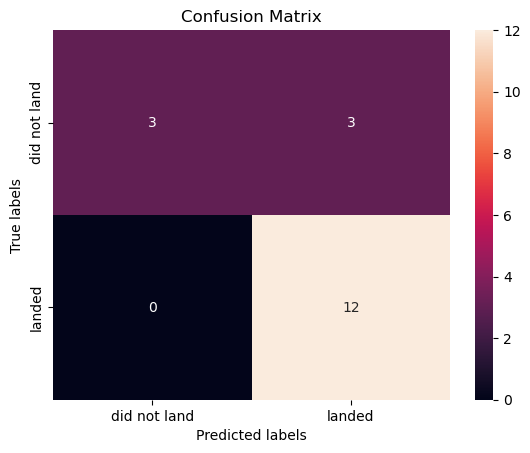

In [36]:
yhat = xgb_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

In [37]:
# Fold XGBoost into the same StratifiedKFold comparison as the other four models,
# so all five are judged on identical, more-robust folds rather than mixing a
# single-split number for XGBoost with cross-validated numbers for the rest.
tuned_models['XGBoost'] = xgb_cv.best_estimator_
xgb_summary = evaluate_with_stratified_kfold({'XGBoost': xgb_cv.best_estimator_}, X, Y, n_splits=10, random_state=2)

cv_summary = pd.concat([cv_summary, xgb_summary])
cv_summary.sort_values('accuracy_mean', ascending=False)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,
SVM,0.855556,0.111665,0.859524,0.102795,0.950000,0.076376,0.899634,0.077927
KNN,0.844444,0.101835,0.836905,0.095987,0.966667,0.066667,0.894322,0.069520
LogisticRegression,0.833333,0.089581,0.814286,0.082685,0.983333,0.050000,0.889011,0.059473
XGBoost,0.811111,0.100000,0.847857,0.108846,0.900000,0.133333,0.862318,0.077067
DecisionTree,0.800000,0.119670,0.858571,0.121923,0.866667,0.145297,0.850310,0.091406


## Explaining the winning model

Explain which features drive the prediction for the best cross-validated model, using SHAP values when the winner is tree-based, or permutation importance otherwise (a model-agnostic fallback).

Best model by cross-validated accuracy: SVM
SHAP unavailable or not applicable (SVM is not tree-based; skipping straight to permutation importance.); falling back to permutation importance.


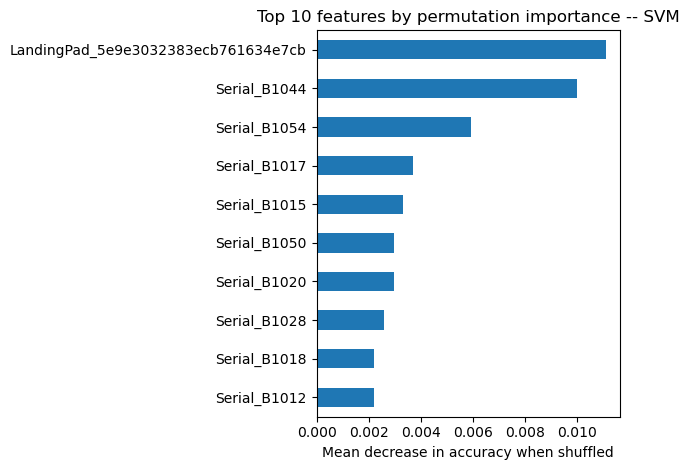

In [38]:
best_model_name = cv_summary["accuracy_mean"].idxmax()
best_model = tuned_models[best_model_name]
# tuned_models holds unfitted clones (cross_validate fits internally per fold
# without keeping a fitted copy) -- fit on the full dataset before explaining it.
best_model.fit(X, Y)
print(f"Best model by cross-validated accuracy: {best_model_name}")

# SHAP's fast TreeExplainer only supports tree-based models (Decision Tree, XGBoost).
# For anything else (Logistic Regression, SVM, KNN), we fall back to permutation
# importance, which is model-agnostic and works regardless of which model won.
tree_based = ('DecisionTree', 'XGBoost')

try:
    if best_model_name not in tree_based:
        raise TypeError(f"{best_model_name} is not tree-based; skipping straight to permutation importance.")
    import shap
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X)
    # Newer SHAP versions return a 3D array (samples, features, classes) for
    # binary classifiers rather than a list of per-class arrays -- keep the
    # positive-class (successful landing) contributions either way.
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig("../docs/images/shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print(f"SHAP unavailable or not applicable ({exc}); falling back to permutation importance.")
    from sklearn.inspection import permutation_importance
    result = permutation_importance(best_model, X, Y, n_repeats=30, random_state=2, scoring='accuracy')
    importances = pd.Series(result.importances_mean, index=feature_names)
    importances.sort_values(ascending=False).head(10).plot(kind="barh")
    plt.xlabel("Mean decrease in accuracy when shuffled")
    plt.title(f"Top 10 features by permutation importance -- {best_model_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("../docs/images/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

## Limitations

- **Sample size.** Only 90 Falcon 9 launches feed the model. That's a small dataset for any classifier, and small enough that cross-validation folds themselves carry real variance (see the std columns above).
- **Feature-to-sample ratio.** After one-hot encoding, `X` has 83 columns for 90 rows -- close to a 1:1 ratio, which is a well-known recipe for overfitting. Tree-based models in particular can memorize idiosyncrasies of this specific dataset rather than learning a generalizable landing-success pattern.
- **Time coverage.** The data runs through 2020-11-13. It does not include the Block 5 fleet's later flight history, Falcon Heavy's most recent missions, or Starship -- all of which could shift what "success" looks like for SpaceX today.
- **Test-set size.** The 18-sample held-out test set (Task 3) is too small to reliably distinguish between models on its own; the StratifiedKFold results above are the more trustworthy comparison, and even those carry non-trivial variance given how little data there is.
- **What the model captures.** It predicts landing success from payload, orbit, site, and booster attributes -- it does not model weather, last-minute technical scrubs, or other operational factors not present in this dataset.

## Business Impact: From Landing Probability to Launch Cost

SpaceX advertises Falcon 9 launches at roughly **$62M** when the first stage is
reused, versus **$165M+** for a comparable expendable launch. The model above
predicts, for a given payload/orbit/site combination, the probability that the
first stage lands successfully -- which is exactly the input needed to turn
that headline cost difference into an *expected* cost for a specific mission,
rather than a single number that applies to "a generic launch."

We model this simply as:

```
expected_cost = p_success * cost_with_reuse + (1 - p_success) * cost_without_reuse
```

This says: if the stage lands, the mission benefits from reuse economics
($62M); if it doesn't, the launch provider effectively eats the cost of an
expendable one ($165M) for that flight. It's a simplification -- SpaceX's
actual internal cost structure isn't public -- but it turns an abstract
landing-probability output into a number that maps onto the question a
customer or competitor actually cares about.

In [39]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

COST_WITH_REUSE = 62_000_000
COST_WITHOUT_REUSE = 165_000_000

def expected_launch_cost(p_success, cost_with_reuse=COST_WITH_REUSE, cost_without_reuse=COST_WITHOUT_REUSE):
    return p_success * cost_with_reuse + (1 - p_success) * cost_without_reuse

# best_model (selected earlier by cross-validated accuracy) may not support
# predict_proba out of the box -- e.g. SVC() was never fit with
# probability=True. CalibratedClassifierCV wraps any classifier and produces
# well-calibrated probabilities via cross-validation, so this works
# regardless of which model happened to win.
if hasattr(best_model, "predict_proba"):
    probability_model = best_model
else:
    print(f"{best_model_name} has no predict_proba; wrapping with CalibratedClassifierCV.")
    probability_model = CalibratedClassifierCV(clone(tuned_models[best_model_name]), cv=5)
    probability_model.fit(X, Y)

print(f"Using {best_model_name} (calibrated: {probability_model is not best_model}) for cost scenarios.")

SVM has no predict_proba; wrapping with CalibratedClassifierCV.
Using SVM (calibrated: True) for cost scenarios.


### Scenario comparison

We hold every feature at its dataset-wide median (or most common value, for
one-hot indicator columns) and vary only payload mass, orbit, and launch site
-- the three variables a mission planner actually chooses. Each scenario's
`PayloadMass`/`Orbit_*`/`LaunchSite_*` values are set explicitly; everything
else stays at the "typical launch" baseline.

In [40]:
orbit_cols = [c for c in feature_names if c.startswith('Orbit_')]
site_cols = [c for c in feature_names if c.startswith('LaunchSite_')]

def build_scenario_row(payload_mass, orbit_col, site_col):
    # Baseline: numeric features at their median, one-hot columns at their
    # most common value (typically 0, except the dominant category).
    row = {}
    for col in feature_names:
        if col in orbit_cols or col in site_cols or col.startswith('LandingPad_') or col == 'Serial':
            row[col] = X_reference[col].mode()[0]
        else:
            row[col] = X_reference[col].median()

    row['PayloadMass'] = payload_mass
    for col in orbit_cols:
        row[col] = 1.0 if col == orbit_col else 0.0
    for col in site_cols:
        row[col] = 1.0 if col == site_col else 0.0
    return row

scenarios = [
    {'label': 'Light payload to LEO (KSC LC-39A)', 'payload_mass': 1000, 'orbit': 'Orbit_LEO', 'site': 'LaunchSite_KSC LC 39A'},
    {'label': 'Medium payload to ISS orbit (CCAFS SLC 40)', 'payload_mass': 4000, 'orbit': 'Orbit_ISS', 'site': 'LaunchSite_CCAFS SLC 40'},
    {'label': 'Heavy payload to GTO (CCAFS SLC 40)', 'payload_mass': 8000, 'orbit': 'Orbit_GTO', 'site': 'LaunchSite_CCAFS SLC 40'},
    {'label': 'Medium payload to Polar orbit (VAFB SLC 4E)', 'payload_mass': 4000, 'orbit': 'Orbit_PO', 'site': 'LaunchSite_VAFB SLC 4E'},
]

scenario_rows = pd.DataFrame([build_scenario_row(s['payload_mass'], s['orbit'], s['site']) for s in scenarios], columns=feature_names)
scenario_rows_scaled = transform.transform(scenario_rows)

p_success = probability_model.predict_proba(scenario_rows_scaled)[:, 1]

results = pd.DataFrame({
    'Scenario': [s['label'] for s in scenarios],
    'Payload (kg)': [s['payload_mass'] for s in scenarios],
    'P(landing success)': p_success,
    'Expected cost ($M)': [expected_launch_cost(p) / 1_000_000 for p in p_success],
})
results

,Scenario,Payload (kg),P(landing success),Expected cost ($M)
0,Light payload to LEO (KSC LC-39A),1000,0.816276,80.923568
1,Medium payload to ISS orbit (CCAFS SLC 40),4000,0.692474,93.675131
2,Heavy payload to GTO (CCAFS SLC 40),8000,0.736492,89.141312
3,Medium payload to Polar orbit (VAFB SLC 4E),4000,0.758016,86.924326


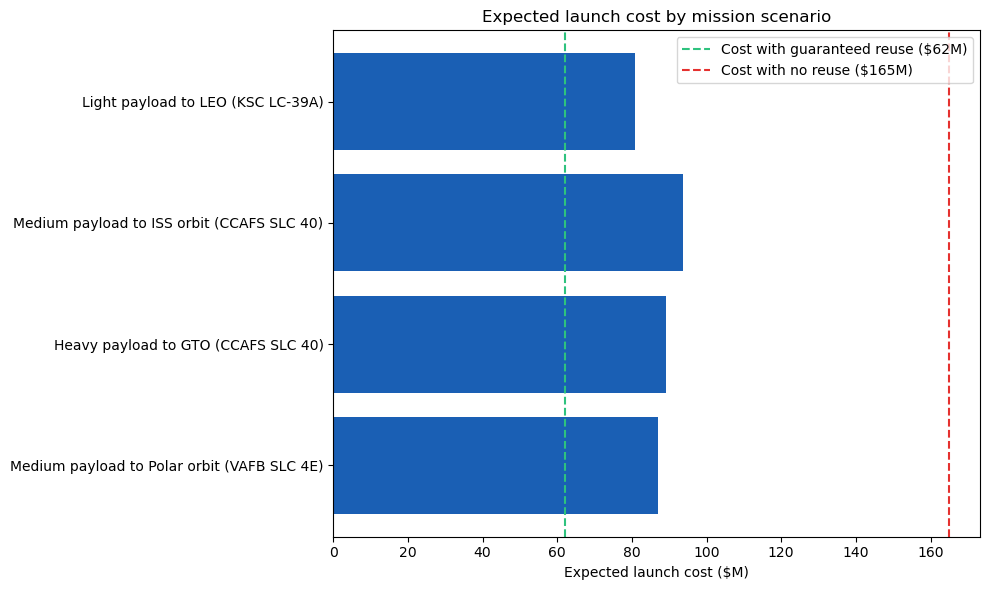

In [41]:
plt.figure(figsize=(10, 6))
plt.barh(results['Scenario'], results['Expected cost ($M)'], color='#1a5fb4')
plt.axvline(COST_WITH_REUSE / 1_000_000, color='#2ec27e', linestyle='--', label='Cost with guaranteed reuse ($62M)')
plt.axvline(COST_WITHOUT_REUSE / 1_000_000, color='#e5312f', linestyle='--', label='Cost with no reuse ($165M)')
plt.xlabel('Expected launch cost ($M)')
plt.legend()
plt.title('Expected launch cost by mission scenario')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/images/expected_cost_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading the scenarios

Missions to orbits and sites where the model predicts a higher landing
probability come out with a lower expected cost -- closer to the $62M
reuse price -- while missions the model considers riskier (heavier
payloads, orbits like GTO with fewer historical successful landings)
drift toward the $165M expendable-launch price. This is a simplification
in several ways worth being explicit about:

- **Cost figures are public marketing figures, not real accounting data.**
  SpaceX has never published its actual internal cost breakdown; $62M/$165M
  are the numbers it advertises publicly.
- **The linear interpolation assumes landing outcome is the only cost driver.**
  In reality, refurbishment cost, booster age, and mission-specific
  insurance also affect the true cost -- this model captures only the
  reuse/no-reuse split.
- **Scenario features are median-filled**, so these are illustrative "typical
  launch" comparisons, not predictions for any specific real mission.